# 04 - Evaluation

Evaluates all three checkpoints from `03_model_training.ipynb` on this
project's custom stratified, held-out **test split** (819 images) — data none
of the three models has seen
during training or validation. This is the honest baseline-vs-transfer-learning
comparison the project is built around, followed by a deeper error analysis of
the best-performing model.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # silence TF/CUDA info-level logs

import sys
from pathlib import Path

import numpy as np
from tensorflow import keras

sys.path.insert(0, str(Path.cwd().parent))

from src.config import BASELINE_MODEL_NAME, MODELS_DIR, TRANSFER_MODEL_NAME
from src.data.dataset import load_datasets
from src.evaluation.metrics import (
    compute_predictions,
    compute_probabilities,
    compute_summary_metrics,
    coverage_selective_accuracy,
    expected_calibration_error,
    get_classification_report,
    most_confused_pairs,
    per_class_f1,
    top_k_accuracy,
)
from src.utils.visualization import (
    plot_confidence_distribution,
    plot_model_comparison,
    plot_most_confused_pairs,
    plot_per_class_f1_extremes,
    plot_prediction_examples,
    plot_reliability_diagram,
    plot_risk_coverage_curve,
    savefig,
)

## Load data and trained checkpoints

Loads the same `test_ds` pipeline used throughout the project (224x224, no
augmentation — augmentation layers are model-internal and inactive at
inference), plus the three `.keras` checkpoints saved by
`03_model_training.ipynb`.

In [2]:
train_ds, val_ds, test_ds, class_names, info = load_datasets()

FINETUNED_MODEL_NAME = f"{TRANSFER_MODEL_NAME}_finetuned"

model_names = [BASELINE_MODEL_NAME, TRANSFER_MODEL_NAME, FINETUNED_MODEL_NAME]
display_names = ["Baseline CNN", "Transfer (frozen)", "Transfer (fine-tuned)"]

models = {
    name: keras.models.load_model(MODELS_DIR / f"{name}.keras") for name in model_names
}
print("Loaded:", list(models.keys()))

Loaded: ['baseline_cnn', 'efficientnetb0_transfer', 'efficientnetb0_transfer_finetuned']


## Test-set accuracy: baseline vs. transfer learning

Runs inference for each checkpoint over the full 819-image test set and
reports overall accuracy plus macro-averaged precision/recall/F1 (macro,
because with 102 uneven classes a micro/weighted average would hide poor
performance on rare classes).

In [3]:
results = {}
predictions = {}

for name in model_names:
    y_true, y_pred, y_conf = compute_predictions(models[name], test_ds)
    predictions[name] = (y_true, y_pred, y_conf)
    results[name] = compute_summary_metrics(y_true, y_pred)
    m = results[name]
    print(
        f"{name:>28}: accuracy={m['accuracy']:.1%}  "
        f"macro_precision={m['macro_precision']:.1%}  "
        f"macro_recall={m['macro_recall']:.1%}  "
        f"macro_f1={m['macro_f1']:.1%}"
    )

                baseline_cnn: accuracy=60.0%  macro_precision=60.6%  macro_recall=55.9%  macro_f1=55.0%


     efficientnetb0_transfer: accuracy=94.4%  macro_precision=95.1%  macro_recall=93.2%  macro_f1=93.6%


efficientnetb0_transfer_finetuned: accuracy=95.8%  macro_precision=96.5%  macro_recall=94.9%  macro_f1=95.2%


PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/04_test_accuracy_comparison.png')

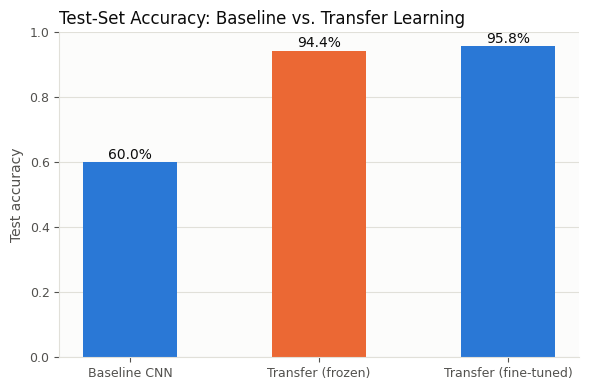

In [4]:
test_accuracies = [results[name]["accuracy"] for name in model_names]

fig = plot_model_comparison(display_names, test_accuracies, title="Test-Set Accuracy: Baseline vs. Transfer Learning")
savefig(fig, "04_test_accuracy_comparison.png")

## Best model: deeper error analysis

Identifies the best-performing checkpoint by test accuracy, then digs into
*where* it fails: the most frequently confused class pairs and the
best/worst-performing individual classes. A full 102x102 confusion matrix is
not readable at any reasonable figure size, so both views extract only the
highest-signal subset (see `docs/architecture.md`).

In [5]:
best_name = max(model_names, key=lambda n: results[n]["accuracy"])
best_display = display_names[model_names.index(best_name)]
y_true, y_pred, y_conf = predictions[best_name]
print(f"Best model: {best_display} ({best_name}.keras) — test accuracy {results[best_name]['accuracy']:.1%}")

Best model: Transfer (fine-tuned) (efficientnetb0_transfer_finetuned.keras) — test accuracy 95.8%


PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/04_most_confused_pairs.png')

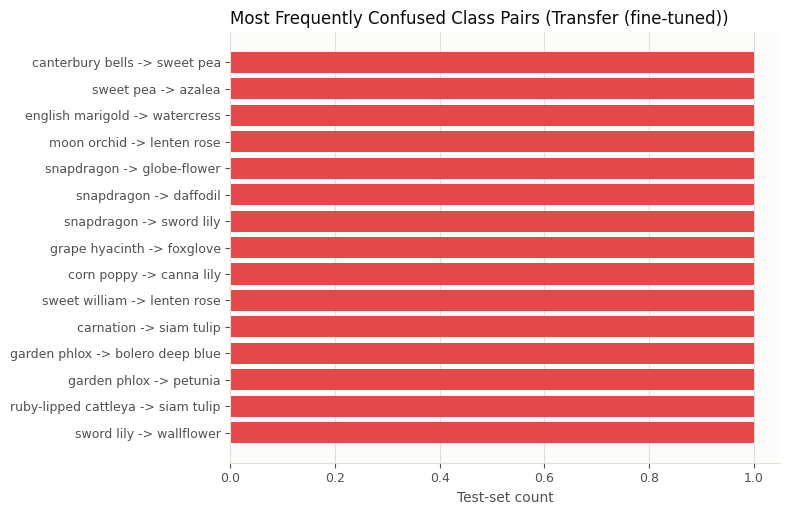

In [6]:
pairs = most_confused_pairs(y_true, y_pred, class_names, top_k=15)
fig = plot_most_confused_pairs(pairs, title=f"Most Frequently Confused Class Pairs ({best_display})")
savefig(fig, "04_most_confused_pairs.png")

PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/04_per_class_f1_extremes.png')

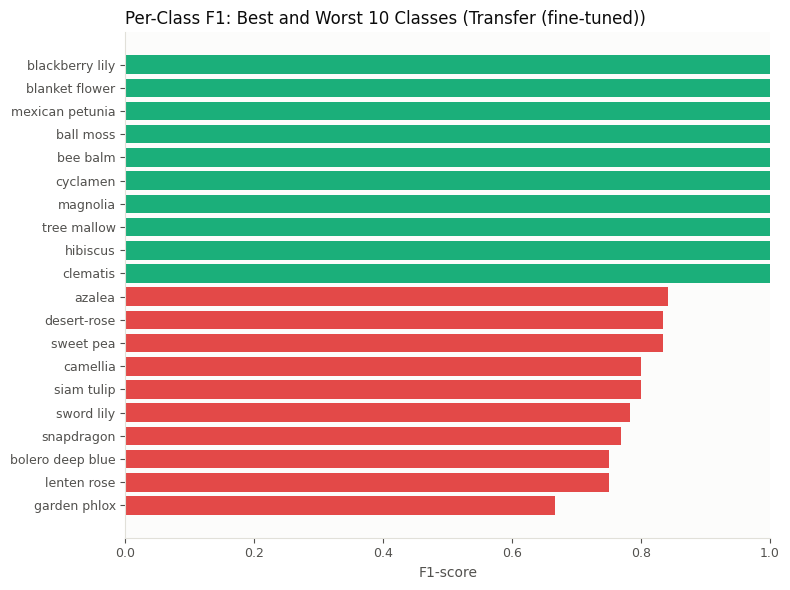

In [7]:
per_class = per_class_f1(y_true, y_pred, class_names)
fig = plot_per_class_f1_extremes(per_class, title=f"Per-Class F1: Best and Worst 10 Classes ({best_display})")
savefig(fig, "04_per_class_f1_extremes.png")

## Sample predictions

A handful of the model's most confident correct predictions, alongside its
most confident *mistakes* — the latter is the more informative story: it shows
whether errors are "reasonable" (visually similar species) or arbitrary.

In [8]:
correct_mask = y_true == y_pred
incorrect_mask = ~correct_mask

correct_idx = np.where(correct_mask)[0]
incorrect_idx = np.where(incorrect_mask)[0]

top_correct = correct_idx[np.argsort(-y_conf[correct_idx])[:6]]
top_incorrect = incorrect_idx[np.argsort(-y_conf[incorrect_idx])[:6]]

selected_idx = set(top_correct.tolist()) | set(top_incorrect.tolist())

selected_images = {}
counter = 0
for images, _ in test_ds:
    for img in images.numpy():
        if counter in selected_idx:
            selected_images[counter] = img
        counter += 1
print(f"Collected {len(selected_images)} sample images")

Collected 12 sample images


PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/04_sample_predictions_correct.png')

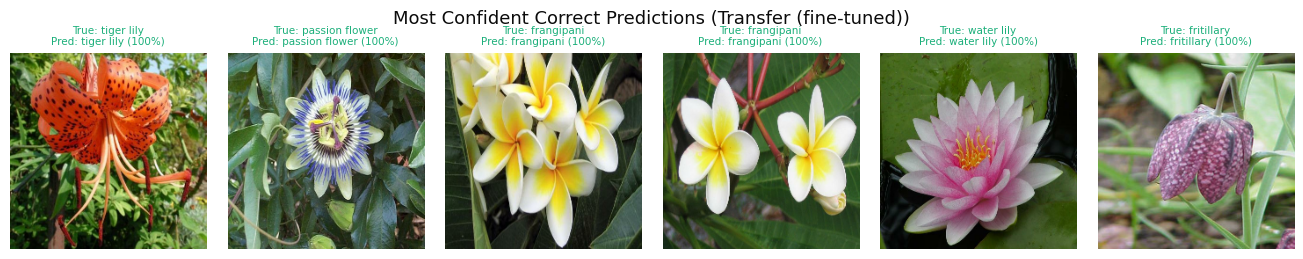

In [9]:
def build_examples(indices):
    images = [selected_images[i] for i in indices]
    true_names = [class_names[y_true[i]] for i in indices]
    pred_names = [class_names[y_pred[i]] for i in indices]
    confidences = [y_conf[i] for i in indices]
    correct = [bool(correct_mask[i]) for i in indices]
    return images, true_names, pred_names, confidences, correct

images, true_names, pred_names, confidences, correct = build_examples(list(top_correct))
fig = plot_prediction_examples(
    images, true_names, pred_names, confidences, correct,
    title=f"Most Confident Correct Predictions ({best_display})",
)
savefig(fig, "04_sample_predictions_correct.png")

PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/04_sample_predictions_incorrect.png')

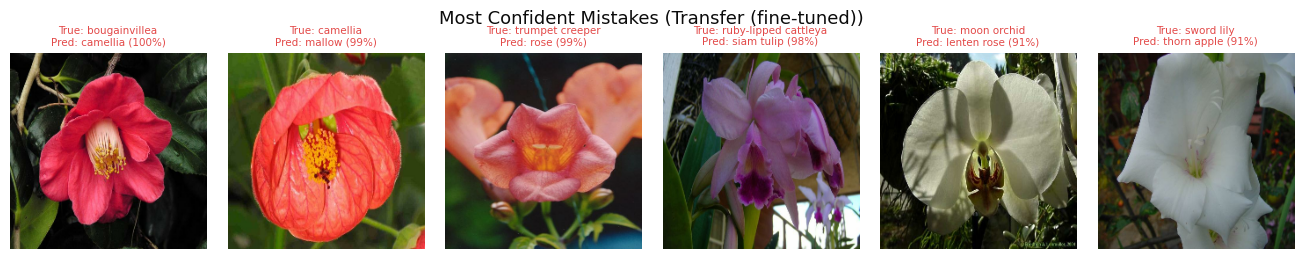

In [10]:
images, true_names, pred_names, confidences, correct = build_examples(list(top_incorrect))
fig = plot_prediction_examples(
    images, true_names, pred_names, confidences, correct,
    title=f"Most Confident Mistakes ({best_display})",
)
savefig(fig, "04_sample_predictions_incorrect.png")

## Top-k accuracy

With 102 fine-grained, visually similar species, top-1 accuracy is a strict
bar — a model that gets the *right family of confusable species* but ranks
the exact one 2nd is still counted as wrong. Top-3 and top-5 accuracy answer
a more business-relevant question: "is the correct species at least among a
short list of suggestions?", which matters for a plant-ID app that can show
several candidates rather than a single guess.

In [11]:
y_true_probs, probs = compute_probabilities(models[best_name], test_ds)

for k in (1, 3, 5):
    acc = top_k_accuracy(y_true_probs, probs, k)
    print(f"Top-{k} accuracy: {acc:.1%}")

Top-1 accuracy: 95.8%
Top-3 accuracy: 99.0%
Top-5 accuracy: 99.3%


## Calibration: is the model's confidence trustworthy?

A model can be accurate on average while still being over- or
under-confident. Calibration checks whether a prediction's stated confidence
(e.g., "92% sure") matches its actual correctness rate — important if the
app is going to show that confidence number to a user, or use it to decide
when to abstain (next section).

Expected Calibration Error (ECE): 0.020  (0 = perfectly calibrated)


PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/04_reliability_diagram.png')

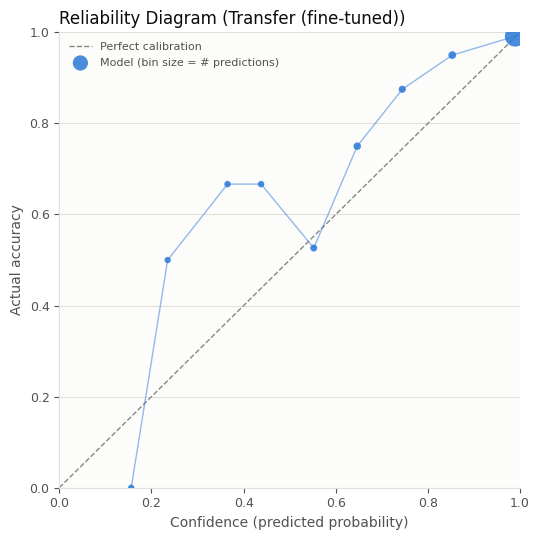

In [12]:
ece, bin_confidences, bin_accuracies, bin_counts = expected_calibration_error(y_true_probs, probs, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece:.3f}  (0 = perfectly calibrated)")

fig = plot_reliability_diagram(bin_confidences, bin_accuracies, bin_counts, title=f"Reliability Diagram ({best_display})")
savefig(fig, "04_reliability_diagram.png")

Mean confidence when correct  : 95.4%
Mean confidence when incorrect: 63.7%


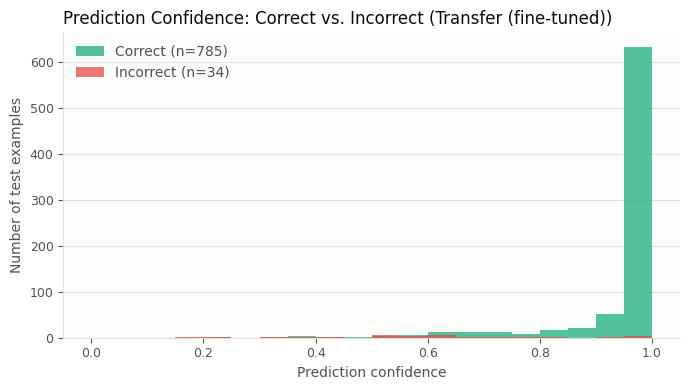

In [13]:
conf_correct = y_conf[correct_mask]
conf_incorrect = y_conf[incorrect_mask]

fig = plot_confidence_distribution(conf_correct, conf_incorrect, title=f"Prediction Confidence: Correct vs. Incorrect ({best_display})")
savefig(fig, "04_confidence_distribution.png")

print(f"Mean confidence when correct  : {conf_correct.mean():.1%}")
print(f"Mean confidence when incorrect: {conf_incorrect.mean():.1%}")

## Confidence-threshold abstention: coverage vs. accuracy trade-off

`docs/business_case.md` recommends flagging low-confidence predictions for
human review rather than presenting them as fact. **Choosing the threshold
itself must not use the test set** — that would be tuning a decision on the
same data used to report final performance. Instead, the trade-off curve
below is computed on the **validation set**; the chosen threshold is then
confirmed, once, on the untouched test set.

[validation] Threshold 0.00: coverage=100.0%  selective_accuracy=95.5%
[validation] Threshold 0.40: coverage=98.4%  selective_accuracy=96.5%
[validation] Threshold 0.70: coverage=92.1%  selective_accuracy=98.9%
[validation] Threshold 0.90: coverage=85.8%  selective_accuracy=99.9%


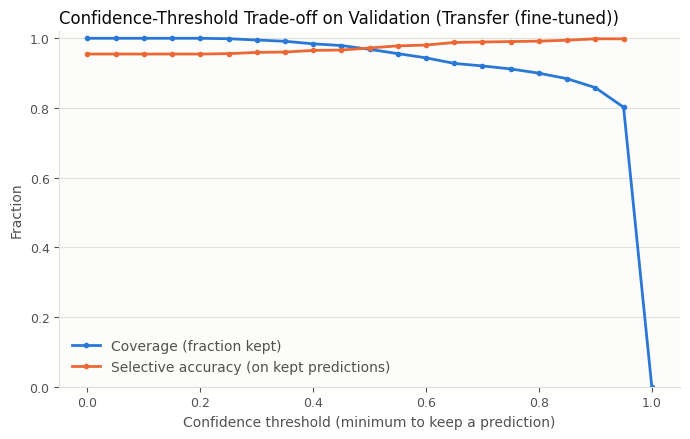

In [14]:
val_true, val_pred, val_conf = compute_predictions(models[best_name], val_ds)

thresholds = np.arange(0.0, 1.01, 0.05)
val_tradeoff = coverage_selective_accuracy(val_true, val_pred, val_conf, thresholds)

val_coverages = np.array([r["coverage"] for r in val_tradeoff])
val_selective_accuracies = np.array([r["selective_accuracy"] for r in val_tradeoff])

fig = plot_risk_coverage_curve(thresholds, val_coverages, val_selective_accuracies, title=f"Confidence-Threshold Trade-off on Validation ({best_display})")
savefig(fig, "04_risk_coverage_curve.png")

for t in (0.0, 0.4, 0.7, 0.9):
    r = next(r for r in val_tradeoff if abs(r["threshold"] - t) < 1e-9)
    print(f"[validation] Threshold {t:.2f}: coverage={r['coverage']:.1%}  selective_accuracy={r['selective_accuracy']:.1%}")

**Interpretation:** on validation data, raising the confidence threshold
trades \emph{coverage} (fraction of photos the app answers automatically)
for accuracy on the ones it keeps. Based on this curve — not the test set —
`app/app.py` uses **0.7** as its abstention threshold.

The cell below confirms, a single time, how that already-chosen threshold
performs on the held-out test set — reporting it, not using it to pick the
threshold.

In [15]:
CHOSEN_THRESHOLD = 0.7
test_tradeoff_at_chosen = coverage_selective_accuracy(y_true, y_pred, y_conf, [CHOSEN_THRESHOLD])[0]
print(f"[test, confirmatory only] Threshold {CHOSEN_THRESHOLD:.2f}: "
      f"coverage={test_tradeoff_at_chosen['coverage']:.1%}  "
      f"selective_accuracy={test_tradeoff_at_chosen['selective_accuracy']:.1%}")

[test, confirmatory only] Threshold 0.70: coverage=91.9%  selective_accuracy=98.5%


## Key takeaways

- Transfer learning beats training from scratch by a very wide margin on this
  ~6,551-image, 102-class, imbalanced training set (60.0% vs. 95.8% test
  accuracy), confirming the hypothesis `docs/architecture.md` is built around.
- Fine-tuning the top backbone layers gives a modest but consistent gain
  over the frozen-backbone model (94.4% -> 95.8% test accuracy). Unfreezing
  a small part of the backbone at a low learning rate improves adaptation to
  the flower dataset without substantially disrupting the pretrained
  representation.
- Macro-averaged F1 is noticeably more informative than plain accuracy here:
  with 102 uneven classes, a handful of consistently hard classes can be
  invisible in the top-line accuracy number but stand out clearly in the
  per-class F1 breakdown above.
- The most frequent confusions are concentrated in a small number of
  visually-similar species pairs rather than being spread uniformly across all
  102 classes — exactly the failure mode the business case (`docs/business_case.md`)
  anticipates, and the reason a confidence-threshold fallback is recommended
  before production use.
- **Top-3 accuracy (99.0%) is much higher than top-1 (95.8%)** — most of the
  model's top-1 mistakes are cases where the right species was its 2nd or 3rd
  guess, not a wild miss. A product that shows a short list of candidates
  rather than one guess would be right almost all the time.
- **The model is well-calibrated** (Expected Calibration Error 0.020) and
  separates its correct from incorrect predictions well by confidence (95.4%
  mean confidence when right vs. 63.7% when wrong) — promising enough to
  support a prototype abstention rule, although further validation would be
  required before deployment.
- **A confidence threshold of 0.7 was chosen on validation data alone**
  (92.1% coverage, 98.9% accuracy there), never on test, then confirmed —
  once — on the held-out test set (91.9% coverage, 98.5% accuracy). At 0.4
  the threshold barely filters anything (98.4% coverage on validation)
  because this model's confidence is well-calibrated and rarely lands in
  that range. `app/app.py` uses 0.7 based on this analysis.
- **Two caveats on this evaluation protocol:** (1) these numbers use this
  project's custom stratified 80/10/10 split, not the dataset's official
  benchmark split, and are therefore **not directly comparable** to published
  Oxford Flowers 102 results. (2) the 819-image test set averages only ~8
  images per class, so per-class F1 and the confusion pairs above should be
  read as indicative, not statistically precise, for any single species.